## Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch

import sys, os
sys.path.append(os.path.join(os.getcwd(), ".."))


from ml_force import MorrisLecar,MorrisLecarCurrent, z_transform, minmax_transform
from ml_force.supervisors import LorenzAttractor, VanDerPol
from ml_force.plots import plot_model
from scipy.signal import find_peaks

## Preparations for Lorenz Attractor

In [2]:
seed = 1
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.random.manual_seed(seed)

T = 25000
dt = 5e-2
t = np.arange(0, T, dt)
nt = t.size
x = LorenzAttractor(T, dt, tau=.01).generate(transient_time=500.0)

x = x.T
# sup = minmax_transform(x, zero_mean=True)
sup = z_transform(x)
print(sup.shape)

(500000, 3)


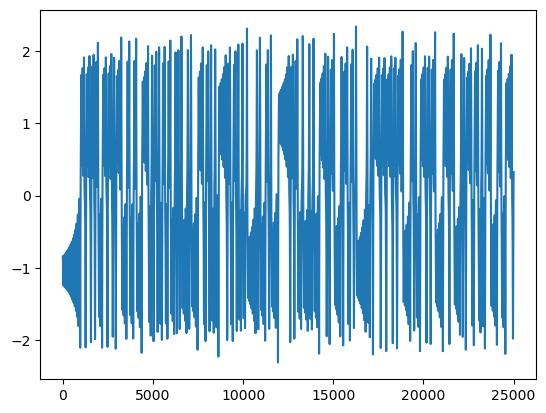

In [3]:
plt.plot(t, sup[:, 0])
plt.show()

# ML Conductance-based Model

In [ ]:
NE = 2000
NI = 2000
N = NI + NE

# input current for I and E neurons
Ie = 75
Ii = 75
current = np.ones((N, 1))
middle = N // 2
current[:middle] *= Ie  # NE bias
current[middle:] *= Ii  # NI bias
# current = np.random.rand(N, 1) * Ie

Q = 150
lamda = 8e-1
gbar = 10

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f"Using Device <{device}> for PyTorch computations...\n")
torch.cuda.random.manual_seed(seed)

try:
    ml = MorrisLecar(supervisor=sup, BIAS=current, T=T, dt=dt, 
                                N=N, Q=Q, gbar=gbar, l=lamda, device=device)
except Exception as e:
    print(e)
    print(torch.cuda.memory_summary(device=device))

In [ ]:
colors = plt.pcolormesh(ml.w.cpu().numpy(), cmap='viridis')
plt.colorbar(colors)
plt.show()

print(f"Mean: {ml.w.type(dtype=torch.float64).mean().item()}, \nSTD: {ml.w.type(dtype=torch.float64).std().item()}")

In [ ]:
# RLS params
# rls_stop = round(T * .6)
rls_start = 500
test_time = 10000    # ms
rls_stop = T - test_time
# rls_stop =
rls_step = 20

In [ ]:
start = time.time() 
random_neurons, voltage_trace, decoder_trace = ml.render(rls_start=rls_start, 
                                                rls_stop=rls_stop, rls_step=rls_step,
                                                live_plot=False, plt_interval=300,
                                                n_neurons=10, save_all=False)
end = time.time()
print(f"Render took {end - start} seconds to finish...\n")

In [ ]:
ml.dec.abs().max().item()

In [ ]:
plot_params = {"rls_start": rls_start,
                "rls_stop": rls_stop,
                "rls_step": rls_step,
                "lamda": lamda,
                "Q": Q,
                "n_vars": min(ml.sup.shape)}

plot_model(ml, "lorenz_conductance", random_neurons, voltage_trace, decoder_trace,
            **plot_params)

In [ ]:
import matplotlib as mpl
mpl.rcParams['font.family'] = "Droid Sans"

test_start = int(rls_stop // dt)
# test_start = 0
dist = 1000
signal = ml.sup[test_start:, 2].cpu().numpy()
# signal = signal[signal > 0]
peaks = find_peaks(signal, distance=dist)[0]
plt.plot(signal[peaks[:-1]], signal[peaks[1:]], 'bo', ms=1, label='supervisor')

signal = ml.x_hat_rec[test_start:, 2].cpu().numpy()
# signal = signal[signal > 0]
peaks = find_peaks(signal, distance=dist)[0]
plt.plot(signal[peaks[:-1]], signal[peaks[1:]], 'ro', ms=1, label='estimator')

plt.legend(loc=0)
# plt.xlim(0, 3)
# plt.ylim(0, 3)
plt.title("Return Map for the Lorenz system estimator")
plt.xlabel(r"prev $x_{max}$")
plt.ylabel(r"$x_{max}$")
plt.grid(alpha=.5)
plt.savefig("img/lorenz_conductance_return_map.jpg", dpi=300, bbox_inches='tight')
plt.show()

# ML Current-based model

In [12]:
NE = 2000
NI = 2000
N = NI + NE

# input current for I and E neurons
Ie = 75
Ii = 75
current = np.ones((N, 1))
middle = N // 2
current[:middle] *= Ie  # NE bias
current[middle:] *= Ii  # NI bias
# current = np.random.rand(N, 1) * Ie

# RLS params
# rls_start = round(T * .02)
rls_start = 500
# rls_stop = round(T * .7)
rls_stop = T - 10000
# rls_stop = -1
rls_step = 20
l_ridge = 0.

Q = 150
lamda = 8e-1
gbar = 15

p_sparsity = .01

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')
print(f"Using Device <{device}> for PyTorch computations...\n")
torch.cuda.random.manual_seed(seed)

try:
    mlc = MorrisLecarCurrent(supervisor=sup, BIAS=current, T=T, dt=dt, 
                                N=N, Q=Q, gbar=gbar, l=lamda, p_sparsity=p_sparsity, 
                                device=device)
except Exception as e:
    print(e)
    print(torch.cuda.memory_summary(device=device))

Using Device <cuda> for PyTorch computations...



In [14]:
# clr = plt.pcolormesh(mlc.w.cpu().numpy(), cmap='viridis')
# plt.colorbar(clr)
# plt.show()

mlc.w.abs().max()

tensor(0.8408, device='cuda:0')

In [15]:
start = time.time() 
mlc_neurons, mlc_v_trace, mlc_dec_trace = mlc.render(rls_start=rls_start, 
                                                rls_stop=rls_stop, rls_step=rls_step,
                                                live_plot=False, plt_interval=300,
                                                n_neurons=10, save_all=False)
end = time.time()
print(f"Render took {end - start} seconds to finish...\n")

100%|██████████| 500000/500000 [27:38<00:00, 301.44it/s]

Render took 1658.7315435409546 seconds to finish...



In [16]:
mlc.dec.abs().max().item()

0.11969155818223953

In [17]:
x_hat_rec = mlc.x_hat_rec.cpu()
# Convert all data to numpy arrays
v_trace = mlc_v_trace.numpy()
sup = mlc.sup.cpu().numpy()

t = mlc.time.cpu().numpy()
x = mlc.sup.cpu().numpy()
N = mlc._N
Ie = mlc._BIAS[0, 0]
Ii = mlc._BIAS[-1, 0]

prefix = "lorenz_current_p_0p01"
plot_params = {"rls_start": rls_start,
                "rls_stop": rls_stop,
                "rls_step": rls_step,
                "lamda": lamda,
                "Q": Q,
                "n_vars": min(mlc.sup.shape)}

plot_model(mlc, prefix, mlc_neurons, mlc_v_trace, mlc_dec_trace, mode='vertical',
            **plot_params)

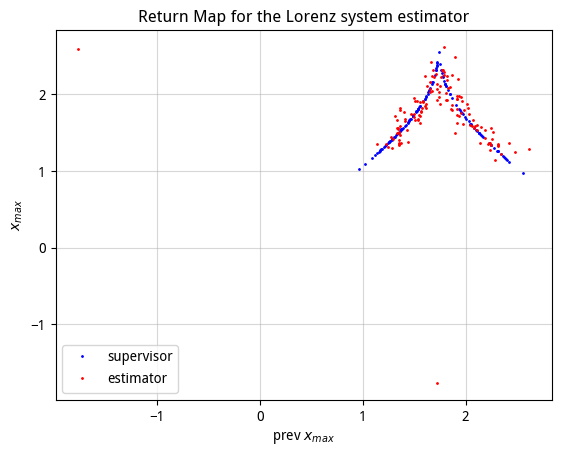

In [18]:
import matplotlib as mpl
mpl.rcParams['font.family'] = "Droid Sans"

test_start = int(rls_stop // dt)
# test_start = 0
dist = 1000
signal = mlc.sup[test_start:, 2].cpu().numpy()
# signal = signal[signal > 0]
peaks = find_peaks(signal, distance=dist)[0]
plt.plot(signal[peaks[:-1]], signal[peaks[1:]], 'bo', ms=1, label='supervisor')

signal = mlc.x_hat_rec[test_start:, 2].cpu().numpy()
# signal = signal[signal > 0]
peaks = find_peaks(signal, distance=dist)[0]
plt.plot(signal[peaks[:-1]], signal[peaks[1:]], 'ro', ms=1, label='estimator')

plt.legend(loc=0)
# plt.xlim(0, 3)
# plt.ylim(0, 3)
plt.title("Return Map for the Lorenz system estimator")
plt.xlabel(r"prev $x_{max}$")
plt.ylabel(r"$x_{max}$")
plt.grid(alpha=.5)
plt.savefig("img/lorenz_current_p_0p01_return_map.jpg", dpi=300, bbox_inches='tight')
plt.show()